In [1]:
import pandas as pd
data = pd.read_csv('../dataset/malgenome.csv')
data

,transact,bindService,onServiceConnected,ServiceConnection,android.os.Binder,READ_SMS,attachInterface,WRITE_SMS,TelephonyManager.getSubscriberId,Ljava.lang.Class.getCanonicalName,...,Ljava.lang.Object.getClass,SET_ORIENTATION,DEVICE_POWER,EXPAND_STATUS_BAR,GET_TASKS,GLOBAL_SEARCH,GET_PACKAGE_SIZE,SET_PREFERRED_APPLICATIONS,android.intent.action.PACKAGE_CHANGED,class
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,S
1,0,0,0,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,0,0,S
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,S
3,0,0,0,0,0,1,0,1,1,0,...,1,0,0,0,0,0,0,0,0,S
4,1,1,1,1,1,1,1,1,1,1,...,1,0,1,0,0,0,0,0,0,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3794,0,1,1,1,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,B
3795,1,1,1,1,1,0,1,0,0,1,...,1,0,0,0,0,0,0,0,0,B
3796,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,B
3797,1,1,1,1,1,0,1,0,0,1,...,1,0,0,0,0,0,0,0,0,B


In [2]:
# Cek jumlah missing value awal
print(data.isna().sum())

# Hapus baris dengan missing value dan simpan hasilnya
data = data.dropna()

# Cek kembali jumlah missing value setelah dihapus
print(data.isna().sum())

transact                                 0
bindService                              0
onServiceConnected                       0
ServiceConnection                        0
android.os.Binder                        0
                                        ..
GLOBAL_SEARCH                            0
GET_PACKAGE_SIZE                         0
SET_PREFERRED_APPLICATIONS               0
android.intent.action.PACKAGE_CHANGED    0
class                                    0
Length: 216, dtype: int64
transact                                 0
bindService                              0
onServiceConnected                       0
ServiceConnection                        0
android.os.Binder                        0
                                        ..
GLOBAL_SEARCH                            0
GET_PACKAGE_SIZE                         0
SET_PREFERRED_APPLICATIONS               0
android.intent.action.PACKAGE_CHANGED    0
class                                    0
Length: 216, dtype: int64


In [3]:
data['class'].value_counts()

class
B    2539
S    1260
Name: count, dtype: int64

In [4]:
# Mapping label
data["class"] = data["class"].map({
    "B": 0,
    "S": 1
})

# Cek distribusi kelas
print(data["class"].value_counts())

class
0    2539
1    1260
Name: count, dtype: int64


In [5]:
# Menghitung jumlah kolom per tipe data
print(data.dtypes.value_counts())

int64    216
Name: count, dtype: int64


In [6]:
# Memisahkan Fitur (X) dan Label (y)
X = data.drop(columns=["class"])
y = data["class"]

# Cek dimensi/ukuran data hasil pemisahan
print("Ukuran Fitur (X):", X.shape)
print("Ukuran Label (y):", y.shape)

Ukuran Fitur (X): (3799, 215)
Ukuran Label (y): (3799,)


In [7]:
# %%
from sklearn.model_selection import train_test_split

# Split pertama: Train + Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split kedua: Validation + Test
# Dari 30% temporary:
# 15% validation + 15% test dari total dataset
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train :", X_train.shape, y_train.shape)
print("Val   :", X_val.shape, y_val.shape)
print("Test  :", X_test.shape, y_test.shape)

Train : (2659, 215) (2659,)
Val   : (570, 215) (570,)
Test  : (570, 215) (570,)


In [8]:
# %%
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape)
print("Val  :", X_val_scaled.shape)
print("Test :", X_test_scaled.shape)

Train: (2659, 215)
Val  : (570, 215)
Test : (570, 215)


In [9]:
# %%
import torch

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.long)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)

print("X_train:", X_train_t.shape)
print("y_train:", y_train_t.shape)

X_train: torch.Size([2659, 215])
y_train: torch.Size([2659])


In [10]:
# %%
from model import build_model
input_dim = X_train_t.shape[1]

model = build_model(
    in_dim=input_dim,
    num_classes=2,
    seed=42
)

print(model)

DrebinModel(
  (theta): FeatureExtractor(
    (fc1): Linear(in_features=215, out_features=64, bias=True)
    (relu1): ReLU()
    (fc2): Linear(in_features=64, out_features=32, bias=True)
    (relu2): ReLU()
  )
  (phi): ClassifierHead(
    (fc): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [11]:
# %%
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

num_epochs = 20

for epoch in range(num_epochs):

    # =========================
    # TRAIN
    # =========================
    model.train()

    optimizer.zero_grad()

    logits = model(X_train_t)

    loss = criterion(logits, y_train_t)

    loss.backward()

    optimizer.step()

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    with torch.no_grad():

        val_logits = model(X_val_t)

        val_loss = criterion(
            val_logits,
            y_val_t
        )

        val_pred = torch.argmax(
            val_logits,
            dim=1
        )

        val_acc = (
            val_pred == y_val_t
        ).float().mean()

    if (epoch + 1) % 5 == 0:

        print(
            f"Epoch [{epoch+1:03d}/{num_epochs}] "
            f"Train Loss: {loss.item():.4f} "
            f"Val Loss: {val_loss.item():.4f} "
            f"Val Acc: {val_acc.item():.4f}"
        )

Epoch [005/20] Train Loss: 0.5902 Val Loss: 0.5726 Val Acc: 0.8684
Epoch [010/20] Train Loss: 0.4796 Val Loss: 0.4655 Val Acc: 0.9158
Epoch [015/20] Train Loss: 0.3784 Val Loss: 0.3671 Val Acc: 0.9509
Epoch [020/20] Train Loss: 0.2975 Val Loss: 0.2878 Val Acc: 0.9614


In [12]:
# %%
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model.eval()

with torch.no_grad():
    test_logits = model(X_test_t)

    test_pred = torch.argmax(
        test_logits,
        dim=1
    )

y_true = y_test_t.numpy()
y_pred = test_pred.numpy()

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="binary"
)

recall = recall_score(
    y_true,
    y_pred,
    average="binary"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="binary"
)

print("Test Accuracy :", accuracy)
print("Test Precision:", precision)
print("Test Recall   :", recall)
print("Test F1       :", f1)

Test Accuracy : 0.9649122807017544
Test Precision: 0.9941520467836257
Test Recall   : 0.8994708994708994
Test F1       : 0.9444444444444444


In [13]:
# %%
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["B", "S"]
    )
)

              precision    recall  f1-score   support

           B       0.95      1.00      0.97       381
           S       0.99      0.90      0.94       189

    accuracy                           0.96       570
   macro avg       0.97      0.95      0.96       570
weighted avg       0.97      0.96      0.96       570



In [14]:
# %%
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[380   1]
 [ 19 170]]


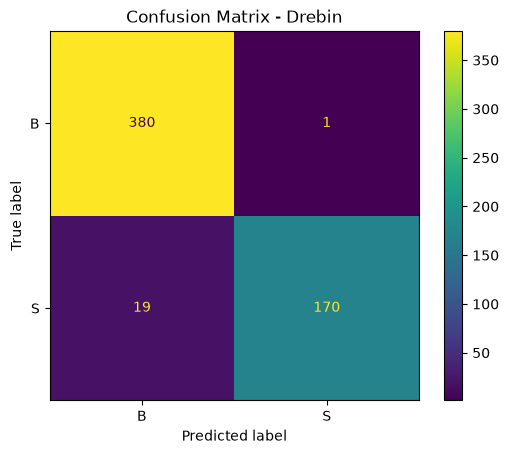

In [15]:
# %%
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["B", "S"]
)

disp.plot()

plt.title("Confusion Matrix - Drebin")
plt.show()